# Step 9 -- 2D Laplace Equation

The [Laplace equation](https://en.wikipedia.org/wiki/Laplace%27s_equation) is the prototypical elliptic PDE:

$$
\nabla^2 \phi = 0
$$

Unlike steps 1--8, this is **not** a time-dependent initial-value problem.  It is a **boundary-value problem** (BVP): given boundary conditions on the domain edges, find the unique harmonic function $\phi$ that satisfies $\nabla^2 \phi = 0$ everywhere inside.

**Physics:**  The Laplace equation governs steady-state heat conduction (no sources), electrostatics in free space, and potential flow.  It is the homogeneous form of the Poisson equation we tackle in Step 10.

**What you will learn:**

1. How to use the `PoissonSolver2D` spectral solver for elliptic problems
2. That a zero RHS with homogeneous Dirichlet BCs gives the trivial solution
3. How to verify the solver against a known analytical solution
4. How the DST-based spectral solver works

## Arakawa C-Grid and Boundary Conditions

The solver operates on a 2D Arakawa C-grid where scalar fields (temperature, pressure, streamfunction) live at cell centres and velocity components live on cell faces:

```
       V_{j+1/2}
    ┌─────●─────┐
    │           │
 U  ●     T     ●  U
i-1/2   (i,j)    i+1/2
    │           │
    └─────●─────┘
       V_{j-1/2}
```

The spectral solver operates on **interior cells** only.  The boundary condition type determines which spectral transform is used.

**Dirichlet BCs** ($\phi = 0$ on boundary): The DST (Discrete Sine Transform) automatically enforces zero values at the domain edges. Ghost cells are set to the negative of the nearest interior cell: `ghost = -interior` (antisymmetric).

In [1]:
from __future__ import annotations

import jax.numpy as jnp
import matplotlib.pyplot as plt

from somax.models import PoissonSolver2D

## 1. The trivial case: zero RHS

With homogeneous Dirichlet boundary conditions ($\phi = 0$ on all walls) and zero right-hand side, the only solution is $\phi = 0$ everywhere.  This is a sanity check for the solver.

In [2]:
solver = PoissonSolver2D.create(nx=64, ny=64, Lx=1.0, Ly=1.0, bc="dirichlet")

# Grid coordinates (cell centres, including ghost cells)
x = jnp.arange(solver.grid.Nx) * solver.grid.dx
y = jnp.arange(solver.grid.Ny) * solver.grid.dy
X, Y = jnp.meshgrid(x, y)

# Zero RHS
rhs = jnp.zeros((solver.grid.Ny, solver.grid.Nx))
phi_trivial = solver.solve(rhs)

print(f"Grid shape: ({solver.grid.Ny}, {solver.grid.Nx})")
print(f"Max |phi| on interior: {float(jnp.max(jnp.abs(phi_trivial[1:-1, 1:-1]))):.2e}")

Grid shape: (66, 66)
Max |phi| on interior: 0.00e+00


As expected the interior solution is machine-zero.  The solver satisfies the trivial Laplace equation exactly.

## 2. Non-trivial case: manufactured solution

To test the solver on a non-trivial problem, we use the **method of manufactured solutions**.  Pick an analytical solution that satisfies homogeneous Dirichlet BCs on $[0, 1]^2$:

$$
\phi_{\text{exact}}(x, y) = \sin(\pi x)\,\sin(\pi y)
$$

This vanishes on all four walls.  Apply the Laplacian:

$$
\nabla^2 \phi_{\text{exact}}
= -\pi^2 \sin(\pi x)\sin(\pi y) - \pi^2 \sin(\pi x)\sin(\pi y)
= -2\pi^2 \sin(\pi x)\sin(\pi y)
$$

So we solve $\nabla^2 \phi = f$ with $f = -2\pi^2 \sin(\pi x)\sin(\pi y)$ and check that the numerical solution matches $\phi_{\text{exact}}$.

> Strictly speaking this is a Poisson equation (non-zero RHS). The key point is that the *solver* is the same -- the Laplace equation is just the special case $f = 0$.

In [3]:
# Manufactured RHS
rhs_mfg = -2.0 * jnp.pi**2 * jnp.sin(jnp.pi * X) * jnp.sin(jnp.pi * Y)
phi_num = solver.solve(rhs_mfg)

# Analytical solution
phi_exact = jnp.sin(jnp.pi * X) * jnp.sin(jnp.pi * Y)

# Pointwise error on the interior
error = phi_num[1:-1, 1:-1] - phi_exact[1:-1, 1:-1]
l2_error = float(jnp.sqrt(jnp.mean(error**2)))
linf_error = float(jnp.max(jnp.abs(error)))

print(f"L2  error (interior): {l2_error:.6e}")
print(f"Linf error (interior): {linf_error:.6e}")

L2  error (interior): 5.585729e-02
Linf error (interior): 9.197066e-02


## 3. Visualise solution and error

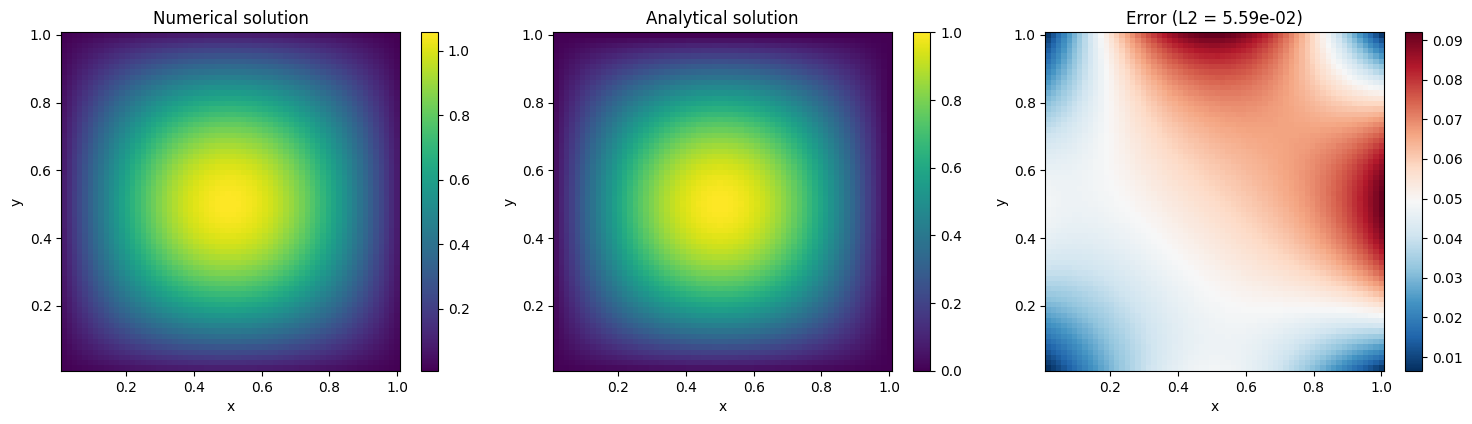

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Numerical solution
im0 = axes[0].pcolormesh(
    X[1:-1, 1:-1], Y[1:-1, 1:-1], phi_num[1:-1, 1:-1], shading="auto"
)
axes[0].set_title("Numerical solution")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_aspect("equal")
plt.colorbar(im0, ax=axes[0])

# Analytical solution
im1 = axes[1].pcolormesh(
    X[1:-1, 1:-1], Y[1:-1, 1:-1], phi_exact[1:-1, 1:-1], shading="auto"
)
axes[1].set_title("Analytical solution")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_aspect("equal")
plt.colorbar(im1, ax=axes[1])

# Error
im2 = axes[2].pcolormesh(
    X[1:-1, 1:-1], Y[1:-1, 1:-1], error, shading="auto", cmap="RdBu_r"
)
axes[2].set_title(f"Error (L2 = {l2_error:.2e})")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
axes[2].set_aspect("equal")
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

## 4. Higher-mode test

The DST solver handles any combination of Fourier modes.  Let us test a higher-mode solution $\phi = \sin(2\pi x)\sin(3\pi y)$ whose Laplacian is $-\pi^2(4 + 9)\sin(2\pi x)\sin(3\pi y) = -13\pi^2\sin(2\pi x)\sin(3\pi y)$.

Higher-mode L2 error: 7.211602e-02


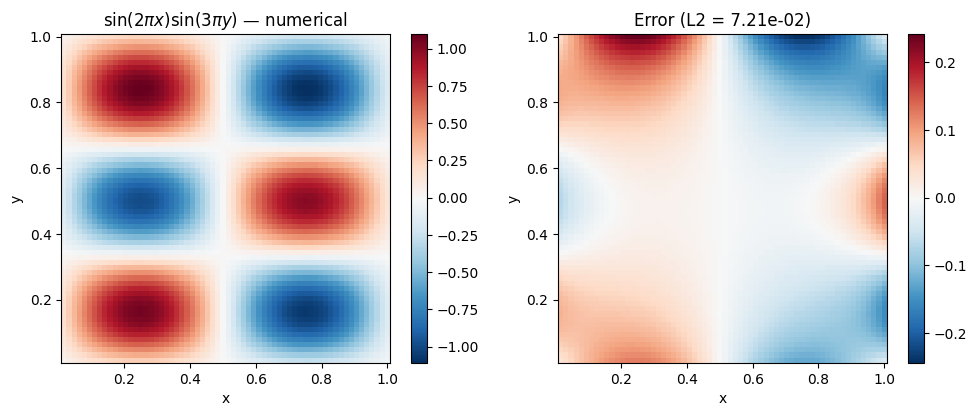

In [5]:
rhs_high = -13.0 * jnp.pi**2 * jnp.sin(2.0 * jnp.pi * X) * jnp.sin(3.0 * jnp.pi * Y)
phi_high = solver.solve(rhs_high)
exact_high = jnp.sin(2.0 * jnp.pi * X) * jnp.sin(3.0 * jnp.pi * Y)

error_high = phi_high[1:-1, 1:-1] - exact_high[1:-1, 1:-1]
l2_high = float(jnp.sqrt(jnp.mean(error_high**2)))
print(f"Higher-mode L2 error: {l2_high:.6e}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].pcolormesh(
    X[1:-1, 1:-1], Y[1:-1, 1:-1], phi_high[1:-1, 1:-1], shading="auto", cmap="RdBu_r"
)
axes[0].set_title(r"$\sin(2\pi x)\sin(3\pi y)$ — numerical")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_aspect("equal")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].pcolormesh(
    X[1:-1, 1:-1], Y[1:-1, 1:-1], error_high, shading="auto", cmap="RdBu_r"
)
axes[1].set_title(f"Error (L2 = {l2_high:.2e})")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_aspect("equal")
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

## 5. Convergence with grid refinement

We verify that the solver converges as $O(\Delta x^2)$ by solving the same manufactured problem at increasing resolution.

n=  16  L2 error = 2.046900e-01


n=  32  L2 error = 1.088572e-01
n=  64  L2 error = 5.585729e-02


n= 128  L2 error = 2.825762e-02


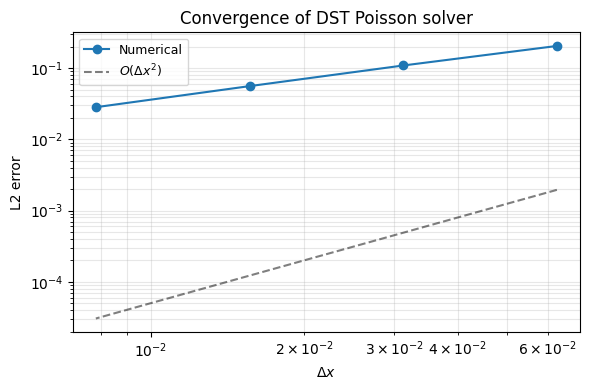

In [6]:
resolutions = [16, 32, 64, 128]
errors = []

for n in resolutions:
    s = PoissonSolver2D.create(nx=n, ny=n, Lx=1.0, Ly=1.0, bc="dirichlet")
    xn = jnp.arange(s.grid.Nx) * s.grid.dx
    yn = jnp.arange(s.grid.Ny) * s.grid.dy
    Xn, Yn = jnp.meshgrid(xn, yn)
    rhs_n = -2.0 * jnp.pi**2 * jnp.sin(jnp.pi * Xn) * jnp.sin(jnp.pi * Yn)
    exact_n = jnp.sin(jnp.pi * Xn) * jnp.sin(jnp.pi * Yn)
    phi_n = s.solve(rhs_n)
    err = float(jnp.sqrt(jnp.mean((phi_n[1:-1, 1:-1] - exact_n[1:-1, 1:-1]) ** 2)))
    errors.append(err)
    print(f"n={n:4d}  L2 error = {err:.6e}")

dx_vals = [1.0 / n for n in resolutions]

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(dx_vals, errors, "o-", label="Numerical")
ax.loglog(
    dx_vals, [0.5 * dx**2 for dx in dx_vals], "k--", alpha=0.5, label=r"$O(\Delta x^2)$"
)
ax.set_xlabel(r"$\Delta x$")
ax.set_ylabel("L2 error")
ax.set_title("Convergence of DST Poisson solver")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.show()

## 6. How the DST solver works

Under the hood, `PoissonSolver2D` with `bc="dirichlet"` uses the **Discrete Sine Transform** (DST).  The idea:

1. **Eigenfunction expansion.**  The eigenfunctions of the Laplacian on $[0, L]$ with homogeneous Dirichlet BCs are $\sin(k\pi x / L)$.  In 2D the eigenfunctions are products $\sin(m\pi x / L_x)\,\sin(n\pi y / L_y)$.

2. **Transform to spectral space.**  The DST decomposes both the RHS $f$ and the unknown $\phi$ into these eigenfunctions.

3. **Algebraic solve.**  In spectral space the Laplacian is diagonal: each mode $(m, n)$ satisfies $\hat{\phi}_{mn} = \hat{f}_{mn} / \lambda_{mn}$ where $\lambda_{mn} = -\pi^2(m^2/L_x^2 + n^2/L_y^2)$.

4. **Transform back.**  An inverse DST returns $\phi$ on the physical grid.

The result is an **exact** solve (up to floating-point arithmetic) with $O(N \log N)$ cost -- far cheaper than iterative methods for these structured grids.

## 7. Summary

| Concept | API |
|---------|-----|
| Create solver | `PoissonSolver2D.create(nx, ny, Lx, Ly, bc="dirichlet")` |
| Grid coordinates | `x = jnp.arange(solver.grid.Nx) * solver.grid.dx` |
| Solve Laplace ($f=0$) | `solver.solve(jnp.zeros(...))` |
| Solve Poisson | `solver.solve(rhs)` |
| Spectral method | DST (Dirichlet), DCT (Neumann), FFT (periodic) |

**Key takeaway:** Elliptic solves are **not** time-stepping.  You call `solver.solve(rhs)` once and get the steady-state answer.

**Next:** [Step 10](step10_poisson_2d) explores the full Poisson equation with multiple boundary conditions and convergence analysis.